# Машинное обучение, DS-поток
## Задание ML.8

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, **не исправляйте и не удаляйте условия!** Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.

**Правила оформления теоретических задач:**

* Решения необходимо прислать в виде $\LaTeX$ в markdown-ячейках.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash;  200 баллов.
* Задача 2 &mdash;  40 баллов.
* Задача 3 &mdash;  50 баллов.


In [ ]:
# Bot check

# HW_ID: ds_ml8
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [62]:
import time
import numpy as np
from collections import defaultdict


import seaborn as sns

colors = [
    '#7570b3',  # глубокий фиолетово-синий — холодный, устойчивый; хорошо идёт для Model1
    '#e7298a',  # насыщенный малиново-розовый — контрастный, подчёркивает test-пары
    '#66a61e',  # тёплый травяной зелёный — сбалансированный, ассоциируется с "хорошими результатами"
    '#1b9e77',  # холодный бирюзово-зелёный — чистый, отлично контрастирует с фиолетом и оранжевым
    '#e6ab02',  # янтарно-жёлтый — нейтральный акцент, подходит для промежуточных серий
    '#d95f02',  # тёплый тыквенно-оранжевый — выразительный, но не кричащий
]

pair_colors = [
    '#1f77b4', '#aec7e8',  # синий
    '#ff7f0e', '#ffbb78',  # оранжевый
    '#2ca02c', '#98df8a',  # зелёный
]


sns.set(style="darkgrid", font_scale=1.3, palette=pair_colors)
import matplotlib.pyplot as plt
from IPython.display import clear_output

import torch
from torch import nn
import torch.nn.functional as F
from torchinfo import summary
import torchvision
from torchvision import transforms
from captum.attr import Occlusion
import captum_visualization as viz

from typing import List, Optional, Tuple, Union
from typing import Callable
from torch.optim import Optimizer
from tqdm.notebook import tqdm
import pandas as pd

N_JOBS = 2
RANDOM_STATE = 42

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

## Исследование свойств сверток

### Задача 1

#### 1. Данные

Обратимся к датасету CIFAR10. Скачаем тренировочную и тестовую части данных.

In [3]:
# Часть данных для обучения
train_dataset = torchvision.datasets.CIFAR10(
    root='./cifar', download=True, train=True, transform=transforms.ToTensor()
)

# Валидационная / тестовая часть данных
val_dataset = torchvision.datasets.CIFAR10(
    root='./cifar', download=True, train=False, transform=transforms.ToTensor()
)

# Классы объектов в датасете
classes = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse', 'ship', 'truck'
)

Проверим размеры датасета.

In [5]:
len(train_dataset), len(val_dataset)

(50000, 10000)

Иллюстрируем 2 примера изображений.

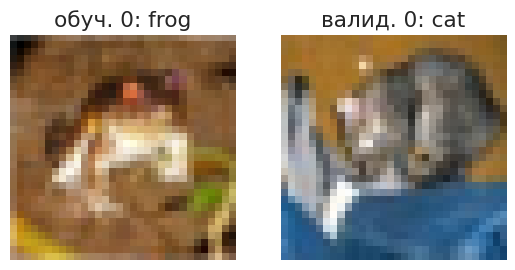

In [6]:
train_idx, val_idx = 0, 0

plt.subplot(1, 2, 1)
plt.imshow(train_dataset[train_idx][0].permute(1, 2, 0))
plt.title(f'обуч. {train_idx}: {classes[train_dataset[train_idx][1]]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(val_dataset[val_idx][0].permute(1, 2, 0))
plt.title(f'валид. {val_idx}: {classes[val_dataset[val_idx][1]]}')
plt.axis('off')

plt.show()

#### 2. Различия между свертками

Постройте модель состоящую из 3 сверточных слоев с параметрами `kernel_size=3` и `stride=1` по правилу
$$INPUT \to [CONV \to RELU]^3 \to POOL \to FC \to RELU \to FC,$$

Также можно пользоваться `Dropout` и `BatchNorm`.
Пример аналогичного построения см. в семинаре.

Посмотрим на размеры сэмплов

In [7]:
next(iter(train_dataset))[0].shape

torch.Size([3, 32, 32])

In [8]:
class MyModel(nn.Module):
    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3)
        self.bn1 = nn.BatchNorm2d(32)
        self.dp1 = nn.Dropout(0.3)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 48, 3)
        self.bn2 = nn.BatchNorm2d(48)
        self.dp2 = nn.Dropout(0.3)
        self.relu2 = nn.ReLU()

        self.conv3 = nn.Conv2d(48, 64, 3)
        self.bn3 = nn.BatchNorm2d(64)
        self.dp3 = nn.Dropout(0.3)
        self.relu3 = nn.ReLU()

        self.mp = nn.MaxPool2d(2)

        # 3x32x32 -> 32x30x30 -> 48x28x28 -> 64x26x26 -> 64x13x13
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 13 * 13, 64)
        self.dp4 = nn.Dropout(0.3)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.mp(x)
        x = self.flatten(x)
        x = self.relu4(self.dp4(self.fc1(x)))
        x = self.fc2(x)

        return x


Выполните следующие действия.
1. Посчитайте общее количество параметров сети и количество параметров в сверточных слоях.
2. Посчитайте затраченную память во время прямого прохода (forward pass) и обратного прохода (backward pass) по сети для одного примера из датасета.
2. Обучите ее на тренировочной части данных и сохраните веса обученной модели.
3. Посчитайте среднее время одного прямого прохода (forward pass) и среднее время обратного прохода (backward pass) по сети во время обучения.
4. Сохраните историю изменения ошибки (loss) и точности (accuracy) во время обучения.


### #1
Посчитаем количество параметров, для начала в свёрточных слоях: у conv1 (3x3x3+1)x32=896, conv2 (3x3x32+1)x48=13872, conv3 (3x3x48+1)x64=27712, суммарно 42480. Далее добавим параметры BatchNorm (по 2 на канал), суммарно (32+48+64)x2=288. Посчитаем параметры полносвязных слоёв: у fc1 (64x13x13+1)x64=692288, у fc2 (64+1)x10=650, суммарно 692938. Тогда всего параметров нейросети 735706. Попрошу гпт красиво вывести

### Подсчёт количества параметров модели

#### Свёрточные слои

| Слой | Формула | Параметров |
|------|----------|-------------|
| Conv1 | $(3 \times 3 \times 3 + 1) \times 32$ | 896 |
| Conv2 | $(3 \times 3 \times 32 + 1) \times 48$ | 13 872 |
| Conv3 | $(3 \times 3 \times 48 + 1) \times 64$ | 27 712 |

**Итого:** 42 480

---

#### Batch Normalization

| Слой | Каналов | Параметров |
|------|----------|-------------|
| BN1 | 32 | 64 |
| BN2 | 48 | 96 |
| BN3 | 64 | 128 |

**Итого:** 288

---

#### Полносвязные слои

| Слой | Формула | Параметров |
|------|----------|-------------|
| FC1 | $(64 \times 13 \times 13) \times 64 + 64$ | 692 288 |
| FC2 | $(64 \times 10) + 10$ | 650 |

**Итого:** 692 938

---

#### Общий результат

| Категория | Параметров |
|------------|-------------|
| Свёрточные | 42 480 |
| BatchNorm | 288 |
| Полносвязные | 692 938 |
| **Всего** | **735 706** |



### #2


Проверим доступ cuda

In [9]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Выполним задание

In [10]:
model = MyModel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.NAdam(model.parameters(), lr=0.001)

loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True)
x, y = next(iter(loader))
x, y = x.to(device), y.to(device)

torch.cuda.empty_cache()
mem0_a = torch.cuda.memory_allocated()
mem0_r = torch.cuda.memory_reserved()

model.train()
logits = model(x)
mem1_a = torch.cuda.memory_allocated()
mem1_r = torch.cuda.memory_reserved()

loss = loss_fn(logits, y)
loss.backward()
mem2_a = torch.cuda.memory_allocated()
mem2_r = torch.cuda.memory_reserved()

print(f"Начальная память: {mem0_a/1024**2:.2f} МБ  (reserved: {mem0_r/1024**2:.2f} МБ)")
print(f"После forward:    {mem1_a/1024**2:.2f} МБ (+{(mem1_a-mem0_a)/1024**2:.2f} МБ)  "
      f"(reserved: {mem1_r/1024**2:.2f} МБ)")
print(f"После backward:   {mem2_a/1024**2:.2f} МБ (+{(mem2_a-mem1_a)/1024**2:.2f} МБ)  "
      f"(reserved: {mem2_r/1024**2:.2f} МБ)")


Начальная память: 2.83 МБ  (reserved: 22.00 МБ)
После forward:    11.92 МБ (+9.09 МБ)  (reserved: 24.00 МБ)
После backward:   21.89 МБ (+9.97 МБ)  (reserved: 44.00 МБ)


Здесь при первом прогоне были одни значения, а затем при каждом прогоне стали как выше. Видимо, при backward, часть памяти, например под вычислительный граф, временные тензоры, освобождается

### #3

In [11]:
def accuracy(logits: torch.Tensor, target: torch.Tensor):
    """Оценка метрики точности для логитов и таргета.

    Args:
        logits (torch.Tensor): Логиты модели (сырые предсказания).
        target (torch.Tensor): Истинные метки.
    """
    return (logits.argmax(dim=1) == target).float().mean().item()

def evaluate(model: nn.Module, loader: torch.utils.data.DataLoader, device: torch.device, criterion: Callable):
    """Оценка лосса и точности для модели.

    Args:
        model (Module): Модель для оценки.
        loader (DataLoader): Загрузчик данных для валидации/теста.
        device (torch.device): Устройство (CPU/GPU), на котором выполняются вычисления.
        criterion (Callable): Функция потерь (лосс).
    """

    # Переводим модель в режим оценки (evaluation mode)
    model.eval()

    # Здесь будем считать общий лосса и точность
    total_loss = 0.0
    total_accuracy = 0.0
    total_size = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            # Получаем предсказания модели и считаем лосс
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            # Считаем точность для текущего батча
            batch_accuracy = accuracy(logits, y_batch)

            # Накапливаем лосс и точность с учетом размера батча
            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_accuracy += batch_accuracy * batch_size
            total_size += batch_size

    # Считаем средние значения лосса и точности по всей выборке
    avg_loss = total_loss / total_size
    avg_accuracy = total_accuracy / total_size
    return avg_loss, avg_accuracy

Для вашего удобства мы уже реализовали класс для подсчета времени работы с помощью `torch.cuda.Event`. Обратим внимание на то, что операции на GPU происходят асинхронно. Поэтому, если мы будем использовать стандартные profiler-ы в python, то момент записи времени окончания операции может не совпадать с реальным временем окончания операции на GPU. Для того, чтобы корректно считать время выполнения операций нужно синхронизировать операции на GPU и CPU с помощью `torch.cuda.synchronize`. Узнать больше об оценки времени на GPU можно [здесь](https://blogs.nvidia.com/blog/category/enterprise/deep-learning/). Для удобства создадим класс таймера, с помощью которого будет происходить измерение времени.

In [12]:
class GPUTimer:
    """
    Класс для корректной оценки времени вычислений на GPU.
    """
    def __init__(self):
        # Заводим starter и ender для оценки времени
        self._starter = torch.cuda.Event(enable_timing=True)
        self._ender = torch.cuda.Event(enable_timing=True)

        # Здесь записывается последняя запись времени
        self.record = None

    def __call__(self, func, *args, **kwargs):
        """
        Параметры
          func - объект, который можно вызвать, например функция;
          *args, **kwargs - аргументы для вызываемого объекта.
        """

        # Устанавливаем время старта
        self._starter.record()

        # Применяем функцию
        output = func(*args, **kwargs)

         # Устаналиваем время окончания
        self._ender.record()

        # Производим синхронизацию: ждем, когда вычиления на GPU будут окончены
        torch.cuda.synchronize()

        # Записываем прошедшее время
        self.record = self._starter.elapsed_time(self._ender)

        return output

In [13]:
def train_one_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: Optimizer,
    device: torch.device,
    criterion: Callable,
    timer: Callable,
):
    """Одна эпоха обучения.

    Args:
        model (Module): Модель для обучения.
        loader (DataLoader): Загрузчик данных для обучения.
        optimizer (Optimizer): Оптимизатор для обновления весов модели.
        device (torch.device): Устройство (CPU/GPU), на котором выполняются вычисления.
        criterion (Callable): Функция потерь (лосс).
    """


    # Переводим модель в режим обучения (training mode)
    model.train()

    # Здесь будем считать общий лосса и точность за эпоху
    running_loss = 0.0
    running_accuracy = 0.0
    running_ftime = 0.0
    running_btime = 0.0
    total_size = 0

    for x_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        # Шаг обучения, при затруднениях посмотри в ноутбуки с занятия
        optimizer.zero_grad()
        out = timer(model, x_batch)
        forward_time = timer.record

        # Вычисляем функцию потерь
        loss = criterion(out, y_batch)
        timer(loss.backward)
        backward_time = timer.record

        optimizer.step()

        # Считаем точность для текущего батча
        batch_accuracy = accuracy(out, y_batch)

        # Накапливаем лосс и точность с учетом размера батча
        batch_size = x_batch.size(0)
        running_loss += loss.item() * batch_size
        running_accuracy += batch_accuracy * batch_size
        running_ftime += forward_time * batch_size
        running_btime += backward_time * batch_size
        total_size += batch_size

    # Считаем средние значения лосса и точности по всей эпохе
    epoch_loss = running_loss / total_size
    epoch_accuracy = running_accuracy / total_size
    epoch_ftime = running_ftime / total_size
    epoch_btime = running_btime / total_size
    return epoch_loss, epoch_accuracy, epoch_ftime, epoch_btime

Запустим обучение с подсчётом времени выполнения

In [45]:
lr = 1e-5
batch_size = 128
num_epochs = 50
N_JOBS = 2
history = defaultdict(lambda: defaultdict(list))

model = MyModel().to(device)
optimizer = torch.optim.NAdam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(reduction='mean')

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size=batch_size,
                                            shuffle=True, num_workers=N_JOBS)
test_loader = torch.utils.data.DataLoader(dataset=val_dataset,
                                          batch_size=batch_size,
                                          shuffle=False, num_workers=N_JOBS)

timer = GPUTimer()
forward_time = []
backward_time = []

for epoch in tqdm(range(num_epochs)):
    epoch_loss, epoch_accuracy, epoch_ftime, epoch_btime = train_one_epoch(model=model,
                                                  loader=train_loader,
                                                  optimizer=optimizer,
                                                  device=device,
                                                  criterion=criterion,
                                                  timer=timer)

    avg_loss, avg_accuracy = evaluate(model=model,
                                      loader=test_loader,
                                      device=device,
                                      criterion=criterion)

    history['loss']['train'].append(epoch_loss)
    history['acc']['train'].append(epoch_accuracy)
    history['loss']['test'].append(avg_loss)
    history['acc']['test'].append(avg_accuracy)
    forward_time.append(epoch_ftime)
    backward_time.append(epoch_btime)

  0%|          | 0/50 [00:00<?, ?it/s]

In [49]:
print(f'Среднее время прямого прохода по всем эпохам: {np.mean(forward_time):.2f}')
print(f'Среднее время обратного прохода по всем эпохам: {np.mean(backward_time):.2f}')

Среднее время прямого прохода по всем эпохам: 6.04
Среднее время обратного прохода по всем эпохам: 12.30


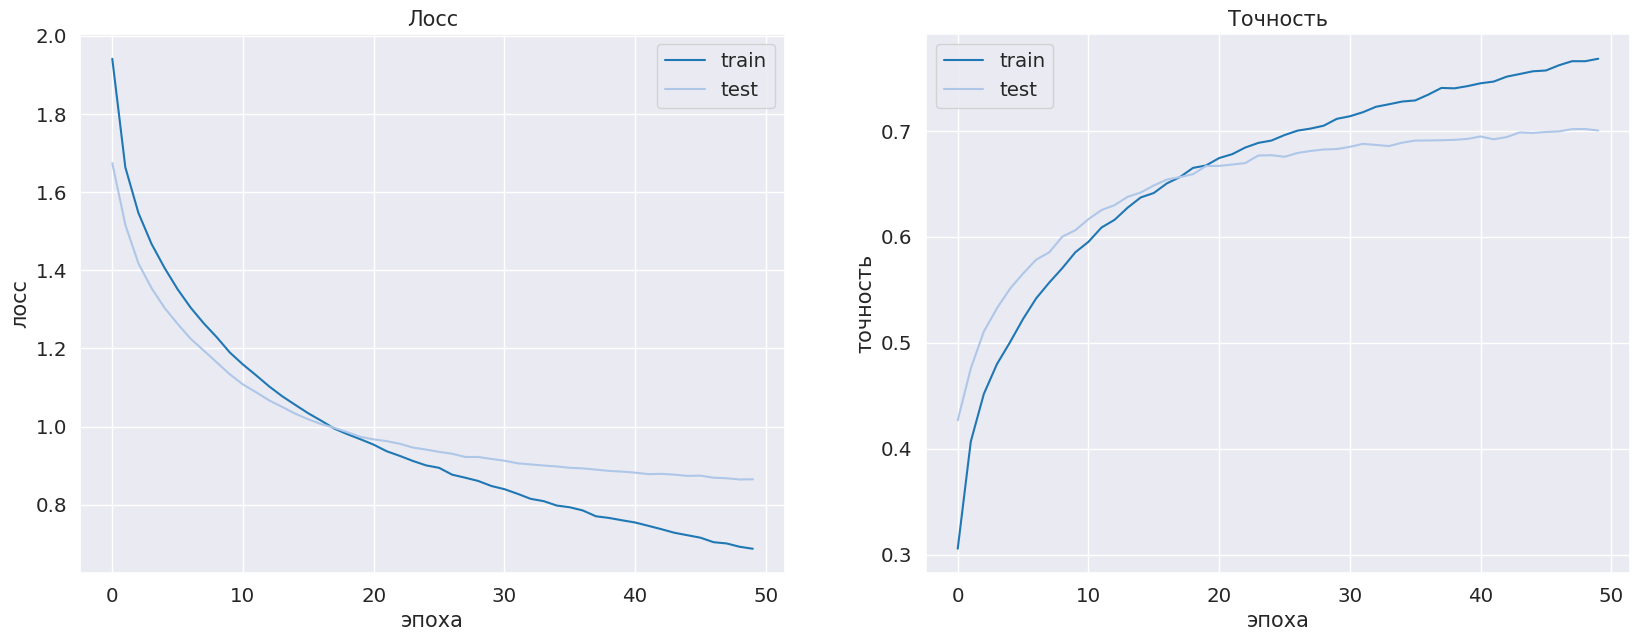

In [63]:
fig = plt.figure(figsize=(20, 7))

plt.subplot(1,2,1)
plt.title(f'Лосс', fontsize=15)
plt.plot(history['loss']['train'], label='train')
plt.plot(history['loss']['test'], label='test')
plt.ylabel('лосс', fontsize=15)
plt.xlabel('эпоха', fontsize=15)
plt.legend()

plt.subplot(1,2,2)
plt.title(f'Точность', fontsize=15)
plt.plot(history['acc']['train'], label='train')
plt.plot(history['acc']['test'], label='test')
plt.ylabel('точность', fontsize=15)
plt.xlabel('эпоха', fontsize=15)
plt.legend()
plt.show()

Сохраним словарь параметров

In [18]:
torch.save({
    'model_state_dict': model.state_dict(),
}, "checkpoint.pth")

Посчитайте область видимости (receptive filed) нейронов последней свертки. Какую область картинки видит нейрон последнего слоя свертки?

**Ответ:** Stride по-умолчанию у слоя conv2d = 1. После первой свёртки область видимости 3x3. Далее 5x5. В последнем слое 7x7=49 пикселей. Затем применяется пуллинг 2x2: 8x8=64 пикселя.

Проведем эксперимент для сравнения работы различных сверток. Для этого постройте еще три модели, которые должны следовать перечисленным ниже требованиям.

Во-первых, необходимо сделать такие модели, у которых область видимости (receptive field) последнего сверточного слоя такая же как у модели построенной ранее. Тогда мы будем ожидать у моделей схожую обобщающую способность.

Во-вторых, установим ограничение на количество каналов в свертках. Оно нужно для корректной оценки параметров и скорости работы сети. Пусть $с_{k,in}$ и $c_{k, out}$ &mdash; количество каналов на входе и на выходе свертки на слое $k$ модели. Тогда сумма $\sum_{k} с_{k,in} c_{k, out}$ должна быть одинаковой для всех моделей, т.е. для исходной и трех новых моделей. Для того, чтобы добиться такого результата, можно дополнительно использовать свертки с `kernel_size=1`. При сравнении моделей в выводе поясните необходимость данного требования.

Наконец, т.к. мы хотим рассмотреть работу различных сверток, то перечислим особенности каждой модели по порядку.

1. Включает в себя свертку c `kernel_size=7, stride=1`.
2. Включает в себя свертку c `kernel_size=5, stride=1`.
3. Включает себя свертки c `kernel_size=3, stride=2`.

$\sum_{k} с_{k,in} c_{k, out} = 4708$

In [25]:
class MyModel1(nn.Module):
    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 7)
        self.bn1 = nn.BatchNorm2d(32)
        self.dp1 = nn.Dropout(0.3)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 48, 1)
        self.bn2 = nn.BatchNorm2d(48)
        self.dp2 = nn.Dropout(0.3)
        self.relu2 = nn.ReLU()

        self.conv3 = nn.Conv2d(48, 64, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.dp3 = nn.Dropout(0.3)
        self.relu3 = nn.ReLU()

        self.mp = nn.MaxPool2d(2)

        # 3x32x32 -> 32x26x26 -> 48x26x26 -> 64x26x26 -> 64x13x13
        # rf=1,j=1-> rf=7,j=1 -> rf=7,j=1 -> rf=7,j=1 -> rf=8,j=2
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 13 * 13, 64)
        self.dp4 = nn.Dropout(0.3)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.mp(x)
        x = self.flatten(x)
        x = self.relu4(self.dp4(self.fc1(x)))
        x = self.fc2(x)

        return x

In [26]:
class MyModel2(nn.Module):
    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 5)
        self.bn1 = nn.BatchNorm2d(32)
        self.dp1 = nn.Dropout(0.3)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 48, 3)
        self.bn2 = nn.BatchNorm2d(48)
        self.dp2 = nn.Dropout(0.3)
        self.relu2 = nn.ReLU()

        self.conv3 = nn.Conv2d(48, 64, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.dp3 = nn.Dropout(0.3)
        self.relu3 = nn.ReLU()

        self.mp = nn.MaxPool2d(2)

        # 3x32x32 -> 32x28x28 -> 48x26x26 -> 64x26x26 -> 64x13x13
        # rf=1,j=1-> rf=5,j=1 -> rf=7,j=1 -> rf=7,j=1 -> rf=8,j=2
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 13 * 13, 64)
        self.dp4 = nn.Dropout(0.3)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.mp(x)
        x = self.flatten(x)
        x = self.relu4(self.dp4(self.fc1(x)))
        x = self.fc2(x)

        return x

In [27]:
class MyModel3(nn.Module):
    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, stride=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.dp1 = nn.Dropout(0.3)
        self.relu1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 48, 3)
        self.bn2 = nn.BatchNorm2d(48)
        self.dp2 = nn.Dropout(0.3)
        self.relu2 = nn.ReLU()

        self.conv3 = nn.Conv2d(48, 64, 1)
        self.bn3 = nn.BatchNorm2d(64)
        self.dp3 = nn.Dropout(0.3)
        self.relu3 = nn.ReLU()

        self.mp = nn.MaxPool2d(2)

        # 3x32x32 -> 32x15x15 -> 48x13x13 -> 64x13х13 -> 64x6x6
        # rf=1,j=1-> rf=3,j=2 -> rf=7,j=1 -> rf=7,j=1 -> rf=8,j=2
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 6 * 6, 64)
        self.dp4 = nn.Dropout(0.3)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.mp(x)
        x = self.flatten(x)
        x = self.relu4(self.dp4(self.fc1(x)))
        x = self.fc2(x)

        return x

Обучите новые модели с теми же параметрами обучения, что и раньше. Для каждой из них посчитайте все характеристики, которые были посчитаны для исходной модели. Сравните результаты и сделайте выводы.

In [33]:
lr = 1e-5
batch_size = 128
num_epochs = 50
history1 = defaultdict(lambda: defaultdict(list))

model1 = MyModel1().to(device)
optimizer1 = torch.optim.NAdam(model1.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(reduction='mean')

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size=batch_size,
                                            shuffle=True, num_workers=N_JOBS)
test_loader = torch.utils.data.DataLoader(dataset=val_dataset,
                                          batch_size=batch_size,
                                          shuffle=False, num_workers=N_JOBS)

timer1 = GPUTimer()
forward_time1 = []
backward_time1 = []

for epoch in tqdm(range(num_epochs)):
    epoch_loss, epoch_accuracy, epoch_ftime, epoch_btime = train_one_epoch(model=model1,
                                                  loader=train_loader,
                                                  optimizer=optimizer1,
                                                  device=device,
                                                  criterion=criterion,
                                                  timer=timer1)

    avg_loss, avg_accuracy = evaluate(model=model1,
                                      loader=test_loader,
                                      device=device,
                                      criterion=criterion)

    history1['loss']['train'].append(epoch_loss)
    history1['acc']['train'].append(epoch_accuracy)
    history1['loss']['test'].append(avg_loss)
    history1['acc']['test'].append(avg_accuracy)
    forward_time1.append(epoch_ftime)
    backward_time1.append(epoch_btime)

  0%|          | 0/50 [00:00<?, ?it/s]

In [34]:
lr = 1e-5
batch_size = 128
num_epochs = 50
history2 = defaultdict(lambda: defaultdict(list))

model2 = MyModel2().to(device)
optimizer2 = torch.optim.NAdam(model2.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(reduction='mean')

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size=batch_size,
                                            shuffle=True, num_workers=N_JOBS)
test_loader = torch.utils.data.DataLoader(dataset=val_dataset,
                                          batch_size=batch_size,
                                          shuffle=False, num_workers=N_JOBS)

timer2 = GPUTimer()
forward_time2 = []
backward_time2 = []

for epoch in tqdm(range(num_epochs)):
    epoch_loss, epoch_accuracy, epoch_ftime, epoch_btime = train_one_epoch(model=model2,
                                                  loader=train_loader,
                                                  optimizer=optimizer2,
                                                  device=device,
                                                  criterion=criterion,
                                                  timer=timer2)

    avg_loss, avg_accuracy = evaluate(model=model2,
                                      loader=test_loader,
                                      device=device,
                                      criterion=criterion)

    history2['loss']['train'].append(epoch_loss)
    history2['acc']['train'].append(epoch_accuracy)
    history2['loss']['test'].append(avg_loss)
    history2['acc']['test'].append(avg_accuracy)
    forward_time2.append(epoch_ftime)
    backward_time2.append(epoch_btime)

  0%|          | 0/50 [00:00<?, ?it/s]

In [36]:
lr = 1e-5
batch_size = 128
num_epochs = 50
history3 = defaultdict(lambda: defaultdict(list))

model3 = MyModel3().to(device)
optimizer3 = torch.optim.NAdam(model3.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss(reduction='mean')

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size=batch_size,
                                            shuffle=True, num_workers=N_JOBS)
test_loader = torch.utils.data.DataLoader(dataset=val_dataset,
                                          batch_size=batch_size,
                                          shuffle=False, num_workers=N_JOBS)

timer3 = GPUTimer()
forward_time3 = []
backward_time3 = []

for epoch in tqdm(range(num_epochs)):
    epoch_loss, epoch_accuracy, epoch_ftime, epoch_btime = train_one_epoch(model=model3,
                                                  loader=train_loader,
                                                  optimizer=optimizer3,
                                                  device=device,
                                                  criterion=criterion,
                                                  timer=timer3)

    avg_loss, avg_accuracy = evaluate(model=model3,
                                      loader=test_loader,
                                      device=device,
                                      criterion=criterion)

    history3['loss']['train'].append(epoch_loss)
    history3['acc']['train'].append(epoch_accuracy)
    history3['loss']['test'].append(avg_loss)
    history3['acc']['test'].append(avg_accuracy)
    forward_time3.append(epoch_ftime)
    backward_time3.append(epoch_btime)

  0%|          | 0/50 [00:00<?, ?it/s]

In [67]:
# pd.DataFrame(data={'forward time': [np.mean(forward_time1), np.mean(forward_time2), np.mean(forward_time3)],
#               'backward time': [np.mean(backward_time1), np.mean(backward_time2), np.mean(backward_time3)], 
#               'train loss': [history1['loss']['train'][-1], history2['loss']['train'][-1], history3['loss']['train'][-1]],
#               'test loss': [history1['loss']['test'][-1], history2['loss']['test'][-1], history3['loss']['test'][-1]], 
#               'train accuracy': [history1['acc']['train'][-1], history2['acc']['train'][-1], history3['acc']['train'][-1]],
#               'test accuracy': [history1['acc']['test'][-1], history2['acc']['test'][-1], history3['acc']['test'][-1]]},
#              index=['Model 1', 'Model 2', 'Model 3'])

df = pd.DataFrame(
    data={
        'forward time': [
            np.mean(forward_time1),
            np.mean(forward_time2),
            np.mean(forward_time3),
            np.mean(forward_time)
        ],
        'backward time': [
            np.mean(backward_time1),
            np.mean(backward_time2),
            np.mean(backward_time3),
            np.mean(backward_time)
        ],
        'train loss': [
            history1['loss']['train'][-1],
            history2['loss']['train'][-1],
            history3['loss']['train'][-1],
            history['loss']['train'][-1]
        ],
        'test loss': [
            history1['loss']['test'][-1],
            history2['loss']['test'][-1],
            history3['loss']['test'][-1],
            history['loss']['test'][-1]
        ],
        'train accuracy': [
            history1['acc']['train'][-1],
            history2['acc']['train'][-1],
            history3['acc']['train'][-1],
            history['acc']['train'][-1]
        ],
        'test accuracy': [
            history1['acc']['test'][-1],
            history2['acc']['test'][-1],
            history3['acc']['test'][-1],
            history['acc']['test'][-1]
        ],
        'parameters': [
            702_682,  # Model1
            712_666,  # Model2
            711_130,  # Model3
            735_706   # Model
        ]
    },
    index=['Model 1', 'Model 2', 'Model 3', 'Model']
)

df


,forward time,backward time,train loss,test loss,train accuracy,test accuracy,parameters
Model 1,3.856661,6.970310,0.840575,0.991559,0.71444,0.6534,702682
Model 2,4.543299,9.287229,0.751746,0.908532,0.74612,0.6841,712666
Model 3,1.393238,2.860395,1.080605,1.063094,0.62188,0.6288,711130
Model,6.037711,12.302192,0.687365,0.865142,0.76814,0.7004,735706


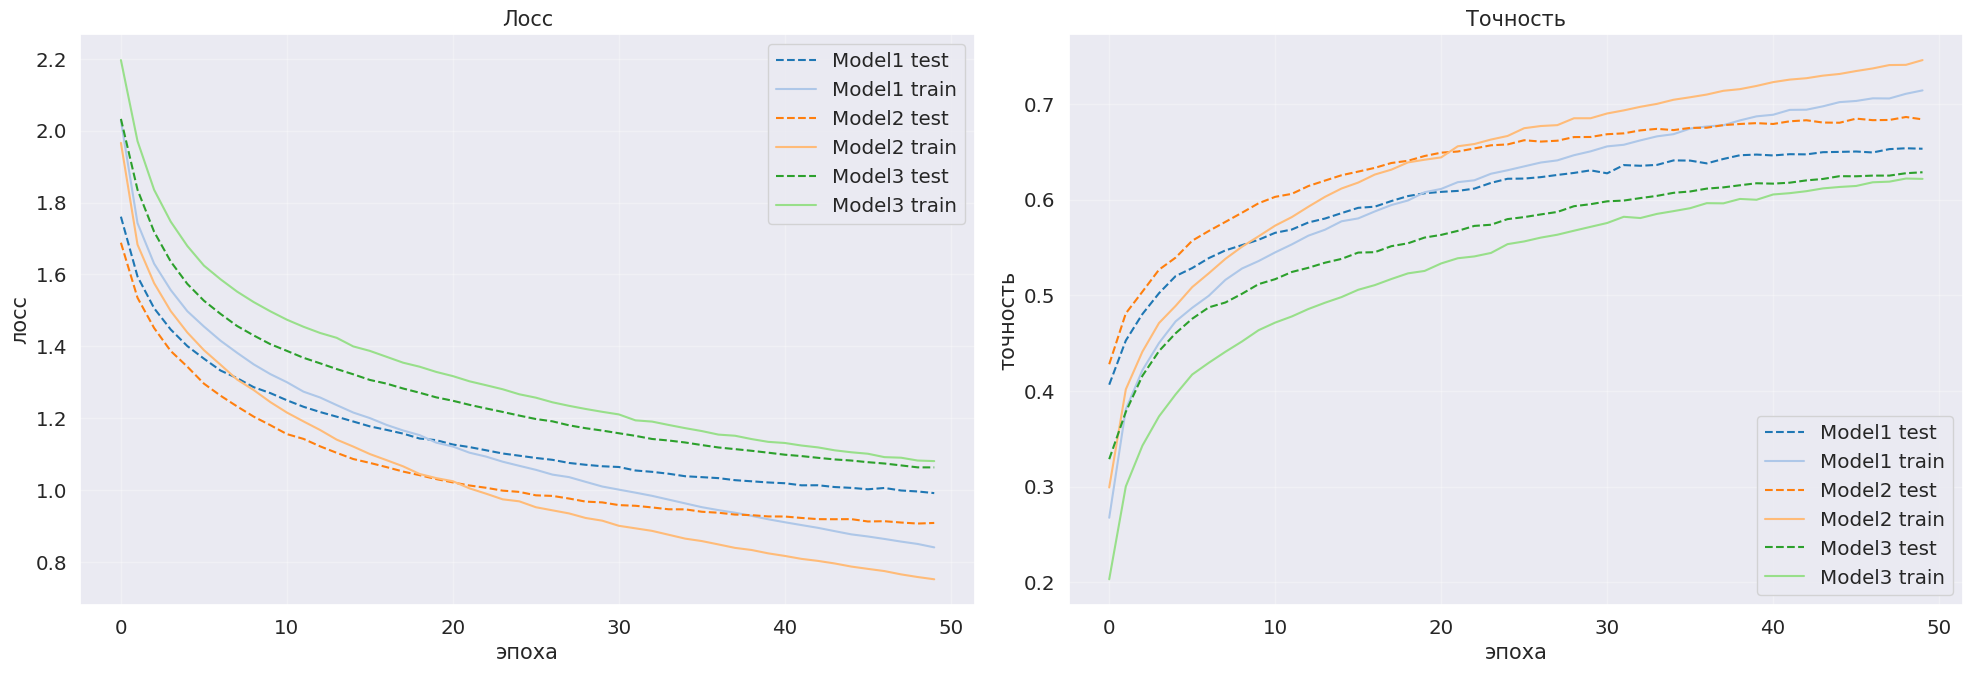

In [64]:
fig = plt.figure(figsize=(20, 7))

# === Лосс ===
plt.subplot(1, 2, 1)
plt.title('Лосс', fontsize=15)
plt.plot(history1['loss']['test'], label='Model1 test', linestyle='--')
plt.plot(history1['loss']['train'], label='Model1 train')
plt.plot(history2['loss']['test'], label='Model2 test', linestyle='--')
plt.plot(history2['loss']['train'], label='Model2 train')
plt.plot(history3['loss']['test'], label='Model3 test', linestyle='--')
plt.plot(history3['loss']['train'], label='Model3 train')
plt.ylabel('лосс', fontsize=15)
plt.xlabel('эпоха', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)

# === Точность ===
plt.subplot(1, 2, 2)
plt.title('Точность', fontsize=15)
plt.plot(history1['acc']['test'], label='Model1 test', linestyle='--')
plt.plot(history1['acc']['train'], label='Model1 train')
plt.plot(history2['acc']['test'], label='Model2 test', linestyle='--')
plt.plot(history2['acc']['train'], label='Model2 train')
plt.plot(history3['acc']['test'], label='Model3 test', linestyle='--')
plt.plot(history3['acc']['train'], label='Model3 train')
plt.ylabel('точность', fontsize=15)
plt.xlabel('эпоха', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [47]:
for i in [1, 2, 3]:
    torch.save({
        f'model{i}_state_dict': model.state_dict(),
    }, f"model{i}.pth")

Черновик вывода


Видим, что модели недоучились, но быстрее всего наилучшего результата достигает модель №2, которая включает в себя ядро размера 5, то есть больше, чем у нашего baseline. Однако все модели хуже baseline. Можно заметить, что хотя параметров модели в model всего лишь примерно на 30000 больше чем в остальных (5%), но время обучения в несколько раз больше. Особенно в сравнении с model3, которая показала и наихудший результат. То есть начиная с некоторого этапа время обучения и точность начинают быстро увеличиваться в зависимости от параметров. Также у model2 и model3 число параметров примерно одинаковое, но качество отличается на 0.06. У model1 меньше всего параметров, но обучается она дольше, чем model3. Во всех моделях одиннаковый receptive field, что сохраняет обобщающую способность всех моделей и сумма попарных произведений количества каналов свёрточных слоёв. Первый канал по сути задаёт глубину ядра в слое, а второй количество ядер в слое. Сумма попарных произведений есть в некотором смысле суммарный объём всех ядер, из размер. Таким образом мы ограничиваем сложность модели. Из этого можно сделать вывод, что на сложность и качество обучения влияет не только количество параметров сети, но и архитекутра.

**Выводы (попросил структурировать у гпт):** 

Видим, что все модели в целом недообучились, однако модель №2 достигает наилучших результатов по качеству среди всех рассмотренных. Она отличается от baseline только увеличенным размером ядра (5×5 вместо 3×3), что, по-видимому, позволяет ей улавливать более сложные пространственные зависимости в изображении.

Тем не менее, все три модели уступают baseline по итоговой точности.

Можно заметить, что, хотя количество параметров в Model всего лишь на ~30 000 больше, чем у остальных (примерно +5 %), время обучения возрастает в несколько раз, особенно в сравнении с Model3. При этом Model3 показывает наихудший результат, что демонстрирует: начиная с некоторого порога сложности, время обучения и качество начинают зависеть нелинейно от числа параметров.

Кроме того, у Model2 и Model3 почти одинаковое количество параметров, но различие в качестве составляет около 0.06 по точности, что указывает на важность архитектуры и топологии слоёв, а не только на размер модели.
Интересно, что Model1 имеет меньше всего параметров, но при этом обучается дольше, чем Model3, что также подтверждает: чистое количество параметров не всегда напрямую связано со скоростью обучения.

Во всех моделях сохраняется одинаковый receptive field, что удерживает их обобщающую способность на одном уровне. При этом можно рассматривать сумму попарных произведений количества каналов свёрточных слоёв как некоторую меру “объёма” модели, аналогичную совокупному размеру всех ядер.
Первый параметр в свёртке определяет глубину ядра, а второй — количество ядер, формирующих выходные карты признаков. Таким образом, этот “объём” отражает совокупную сложность модели.

В целом можно заключить, что на сложность и качество обучения влияет не только число параметров, но и организация архитектуры — конкретные размеры ядер, связи между слоями и структура активаций.

#### 3. Интерпретируемость
В этой части задания вы попробуете еще один способ интерпретации работы сверточных слоев. На лекции и семинаре для того, чтобы показать что нейроны реагируют на отдельные части изображения, использовались выходы сети целиком. Сейчас же вы сможете проверить, есть ли интерпретируемость на уровне сверточных слоев.

1. Выделите 5 изображений лягушек и 5 изображений самолетов из датасета.
2. Выберете одну из четырех обученных моделей.
3. Для каждого изображения посчитайте выходы последнего сверточного слоя модели и найдите максимумы по каналам. Должен получиться квадратный двумерный тензор для каждого изображения. Он показывает на какие области больше всего реагирует сеть для предсказания соотвествующего класса.  
4. Отобразите результат для каждого изображения.
5. Сравните активации для изображений одного класса и различных классов. Сделайте выводы.

In [102]:
frog_idx, plane_idx = [], []
i = 0
while len(frog_idx) < 5:
    if classes[train_dataset[i][1]] == 'frog':
        frog_idx.append(i)
    i += 1

i = 0
while len(plane_idx) < 5:
    if classes[train_dataset[i][1]] == 'plane':
        plane_idx.append(i)   
    i += 1

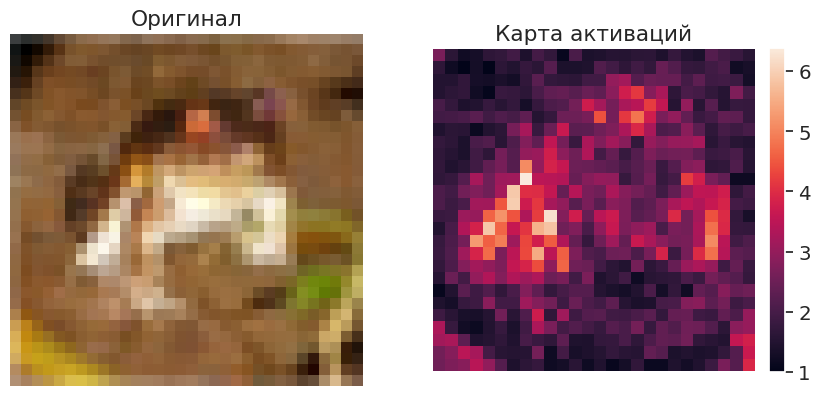

          Probs
plane  0.001573
car    0.000317
bird   0.010681
cat    0.228402
deer   0.032376
dog    0.198001
frog   0.512829
horse  0.014210
ship   0.001156
truck  0.000454


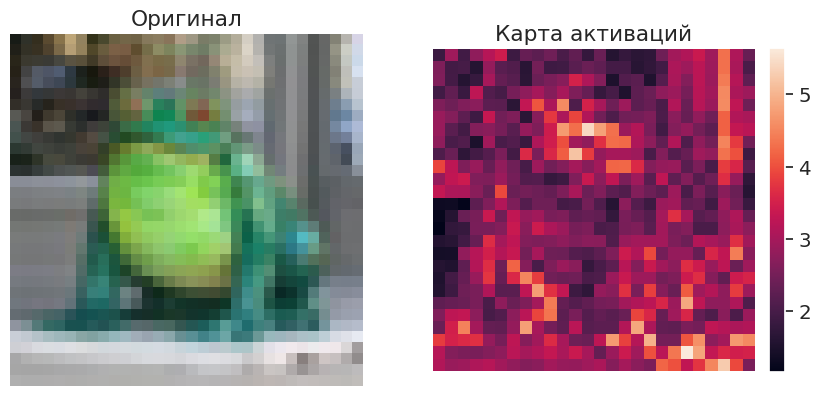

          Probs
plane  0.003420
car    0.025685
bird   0.029360
cat    0.018200
deer   0.036030
dog    0.003216
frog   0.774677
horse  0.006084
ship   0.000594
truck  0.102733


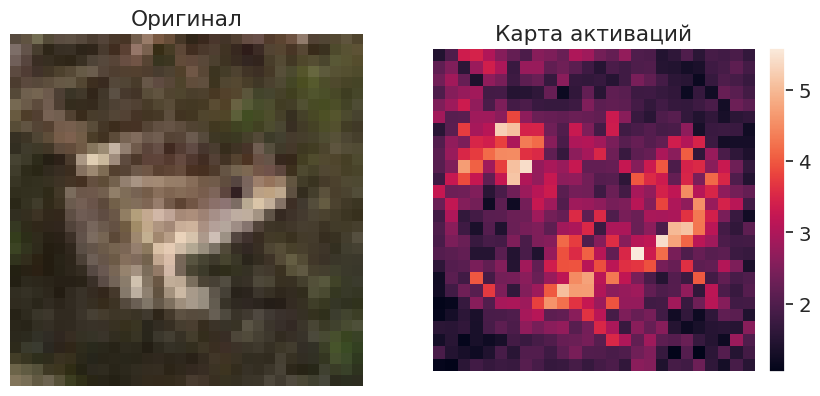

          Probs
plane  0.000030
car    0.000297
bird   0.001119
cat    0.008404
deer   0.006654
dog    0.003596
frog   0.979665
horse  0.000051
ship   0.000154
truck  0.000029


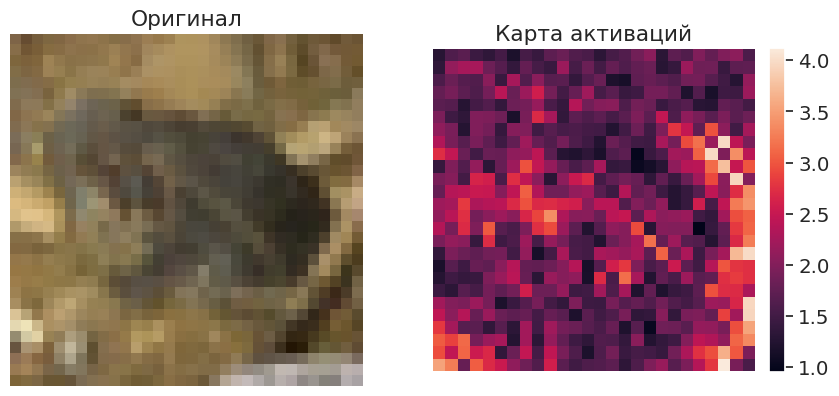

          Probs
plane  0.000255
car    0.000468
bird   0.051260
cat    0.036203
deer   0.028849
dog    0.008020
frog   0.871723
horse  0.002056
ship   0.000700
truck  0.000465


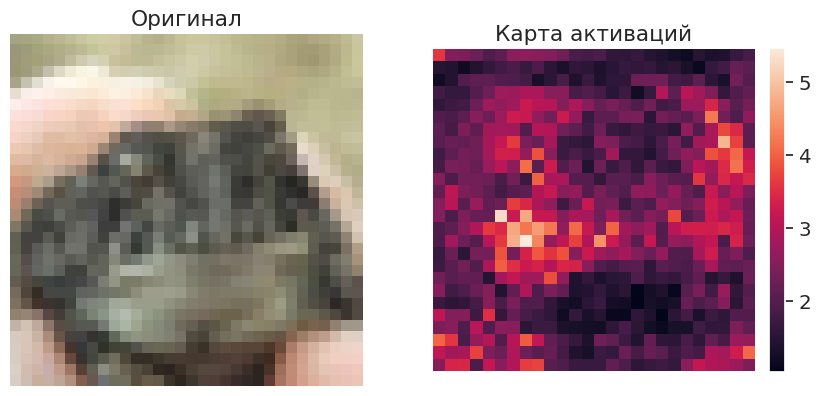

          Probs
plane  0.001422
car    0.003397
bird   0.009111
cat    0.177609
deer   0.002313
dog    0.023948
frog   0.768139
horse  0.008063
ship   0.002750
truck  0.003248


In [183]:
model.eval()
model.cpu()
for idx in frog_idx:
    x0 = train_dataset[idx][0].cpu()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(x0.permute(1, 2, 0))
    axes[0].set_title("Оригинал")
    axes[0].axis("off")

    x1 = x0.unsqueeze(0)
    x = model.relu1(model.bn1(model.conv1(x1)))
    x = model.relu2(model.bn2(model.conv2(x)))
    x = model.relu3(model.bn3(model.conv3(x)))
    y = x.max(axis=1).values

    im = axes[1].imshow(y.squeeze(0).detach().numpy())
    axes[1].set_title("Карта активаций")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.show()
    print(pd.DataFrame(data={'Probs': nn.Softmax(dim=0)(model(x1).squeeze(0)).detach().numpy()}, index=classes, ))

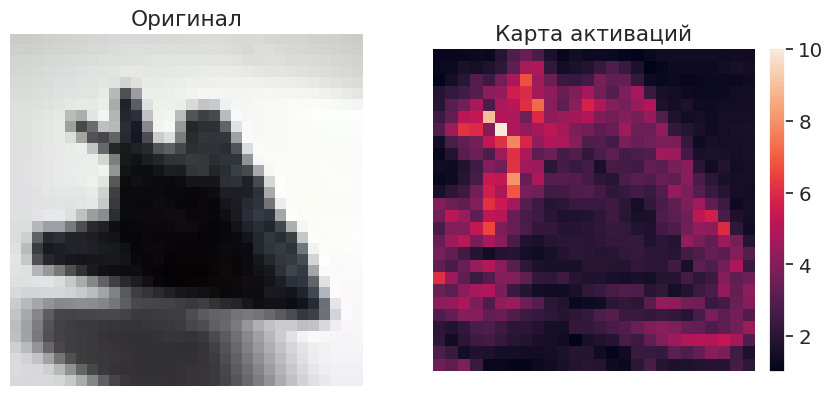

          Probs
plane  0.684424
car    0.038418
bird   0.100094
cat    0.023220
deer   0.005027
dog    0.017046
frog   0.002932
horse  0.008257
ship   0.112937
truck  0.007646


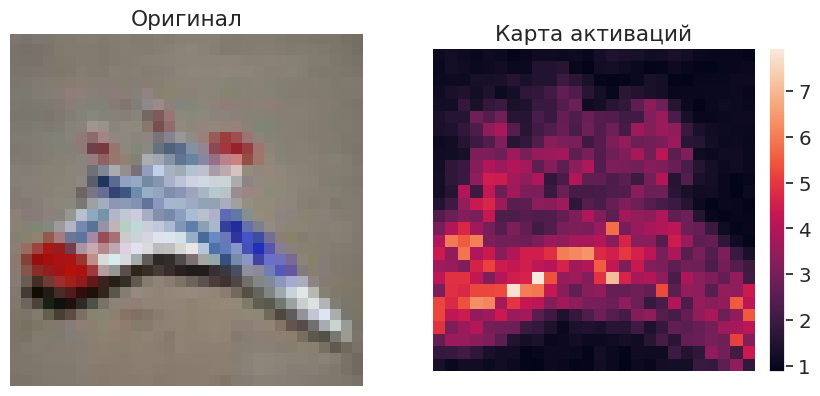

          Probs
plane  0.942764
car    0.014553
bird   0.027106
cat    0.000258
deer   0.000073
dog    0.000547
frog   0.003006
horse  0.000097
ship   0.007945
truck  0.003652


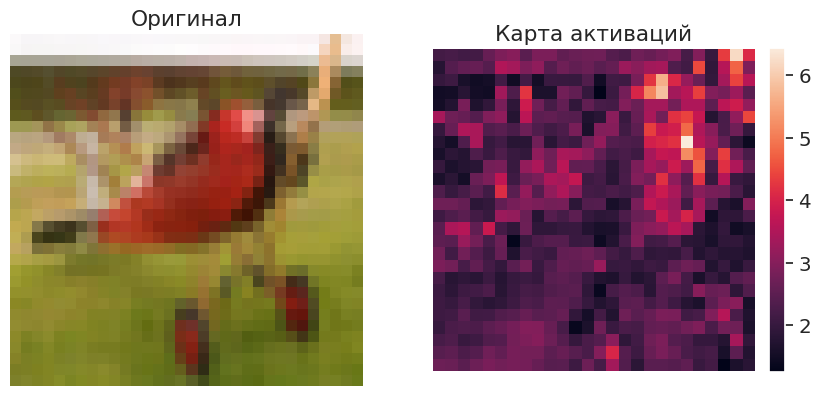

          Probs
plane  0.150849
car    0.033333
bird   0.307832
cat    0.002866
deer   0.098230
dog    0.028774
frog   0.002416
horse  0.330428
ship   0.005192
truck  0.040081


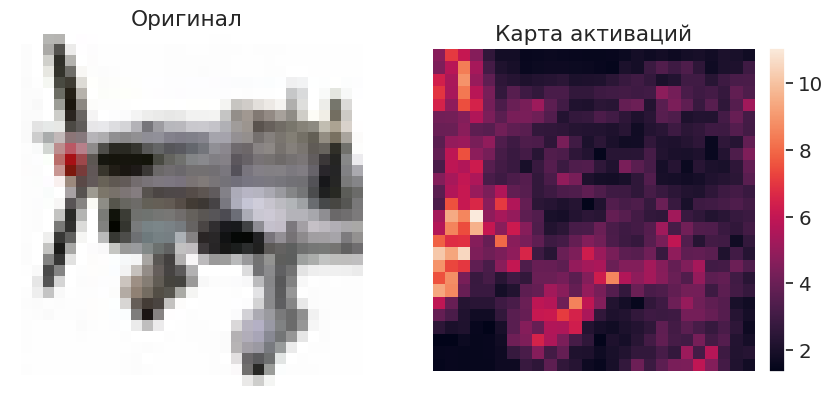

          Probs
plane  0.900425
car    0.005721
bird   0.002750
cat    0.025189
deer   0.012510
dog    0.002423
frog   0.005354
horse  0.036715
ship   0.001908
truck  0.007004


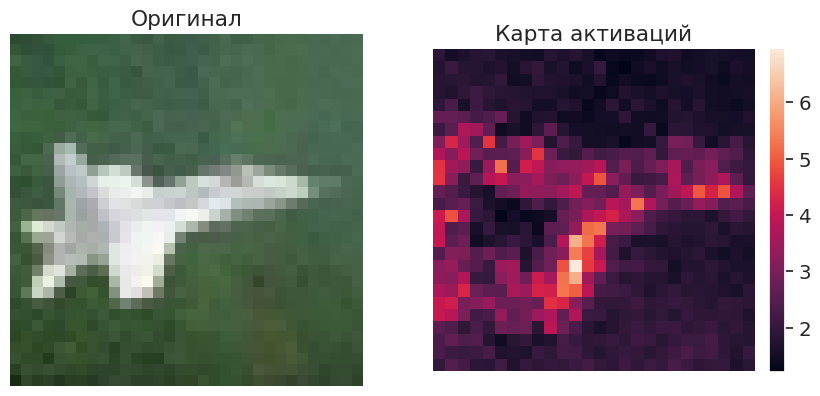

          Probs
plane  0.867375
car    0.017697
bird   0.010288
cat    0.006897
deer   0.043905
dog    0.012240
frog   0.001638
horse  0.009094
ship   0.028205
truck  0.002662


In [189]:
model.eval()
model.cpu()
for idx in plane_idx:
    x0 = train_dataset[idx][0].cpu()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(x0.permute(1, 2, 0))
    axes[0].set_title("Оригинал")
    axes[0].axis("off")

    x1 = x0.unsqueeze(0)
    x = model.relu1(model.bn1(model.conv1(x1)))
    x = model.relu2(model.bn2(model.conv2(x)))
    x = model.relu3(model.bn3(model.conv3(x)))
    y = x.max(axis=1).values

    im = axes[1].imshow(y.squeeze(0).detach().numpy())
    axes[1].set_title("Карта активаций")
    axes[1].axis("off")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.show()
    print(pd.DataFrame(data={'Probs': nn.Softmax(dim=0)(model(x1).squeeze(0)).detach().numpy()}, index=classes))

**Вывод:** У самолёта сетка выделяет края, в особенности крылья, хвост и лопасти, которые строгие, острые. У лягушки же края гладкие, есть сопоставимая по размеру круглая голова, есть лапки, узодящие обе вниз

На семинаре мы реализовали окклюзию самостоятельно, но она реализована и в библиотеке Captum. Выберите другие 2 класса и примените окклюзию к 5 случайным представителям из каждого класса. Пример визуализации в Captum смотрите в семинаре. Что модель считает важным для определения выбранных классов?

In [190]:
car_idx, bird_idx = [], []
i = 0
while len(car_idx) < 5:
    if classes[train_dataset[i][1]] == 'car':
        car_idx.append(i)
    i += 1

i = 0
while len(bird_idx) < 5:
    if classes[train_dataset[i][1]] == 'bird':
        bird_idx.append(i)   
    i += 1

cars = [train_dataset[i][0].unsqueeze(0) for i in car_idx]
birds = [train_dataset[i][0].unsqueeze(0) for i in bird_idx]

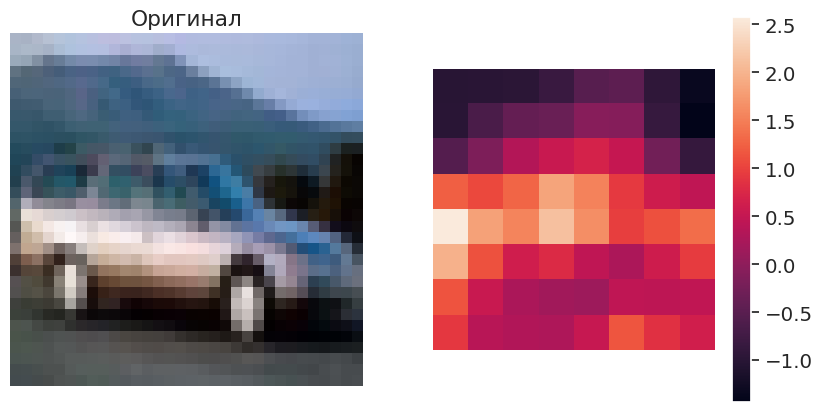

          Probs
plane  0.031824
car    0.768480
bird   0.001149
cat    0.000032
deer   0.000222
dog    0.000039
frog   0.000058
horse  0.001776
ship   0.014812
truck  0.181609


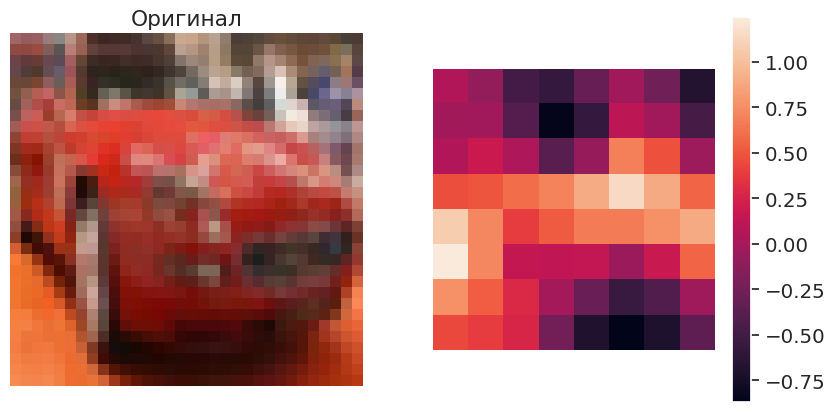

          Probs
plane  0.005040
car    0.791423
bird   0.001831
cat    0.002695
deer   0.005175
dog    0.027539
frog   0.004517
horse  0.063836
ship   0.004969
truck  0.092974


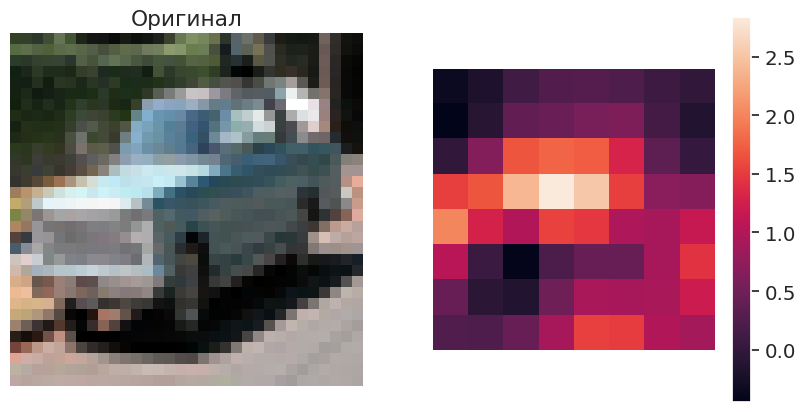

              Probs
plane  1.525345e-05
car    9.859009e-01
bird   8.268997e-06
cat    6.128829e-07
deer   1.063824e-07
dog    1.253743e-07
frog   1.653358e-06
horse  7.196215e-08
ship   7.277109e-05
truck  1.400024e-02


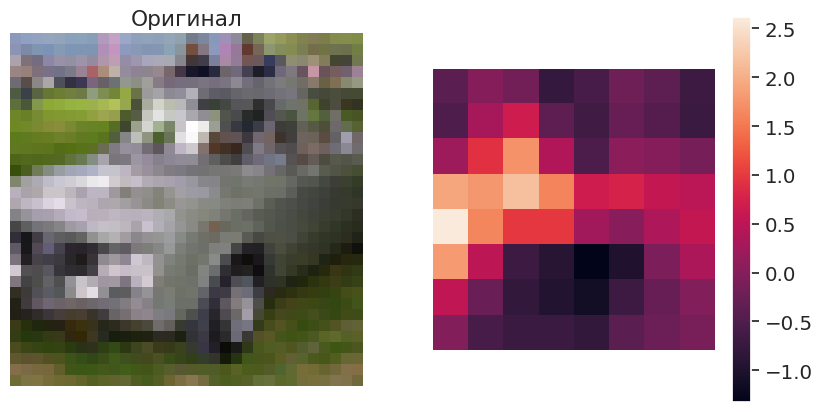

          Probs
plane  0.027506
car    0.553575
bird   0.018421
cat    0.013832
deer   0.208192
dog    0.005012
frog   0.038268
horse  0.102547
ship   0.005465
truck  0.027182


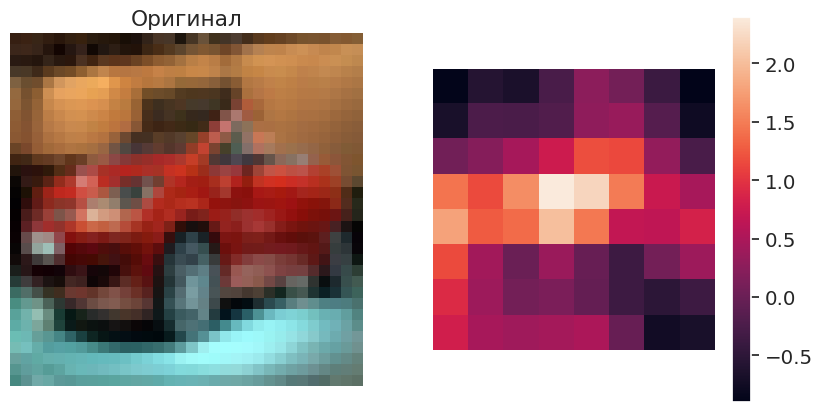

          Probs
plane  0.002564
car    0.890128
bird   0.000110
cat    0.000366
deer   0.000145
dog    0.000325
frog   0.000196
horse  0.000075
ship   0.021625
truck  0.084466


In [217]:
model.eval()
model.cpu()
occlusion = Occlusion(model.forward)

for idx in car_idx:
    x0 = train_dataset[idx][0].cpu()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(x0.permute(1, 2, 0))
    axes[0].set_title("Оригинал")
    axes[0].axis("off")

    x = x0.unsqueeze(0) 
    attr = occlusion.attribute(
        x,
        target=class_idx,
        sliding_window_shapes=(3, 8, 8),
        strides=(3, 4, 4)
    )
    heatmap = heatmap = attr.squeeze(0).max(axis=0).values.detach().numpy()
    plt.imshow(heatmap)
    plt.axis('off')
    plt.colorbar()
    plt.show()
    print(pd.DataFrame(data={'Probs': nn.Softmax(dim=0)(model(x).squeeze(0)).detach().numpy()}, index=classes))

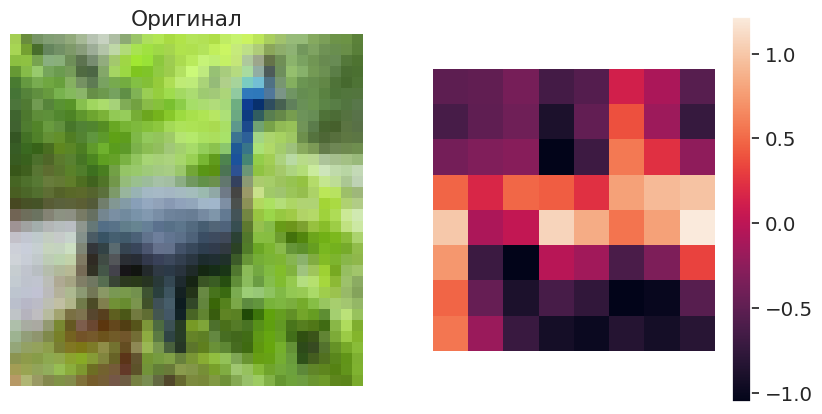

          Probs
plane  0.017612
car    0.031807
bird   0.485477
cat    0.008574
deer   0.201447
dog    0.012511
frog   0.211119
horse  0.012808
ship   0.000284
truck  0.018361


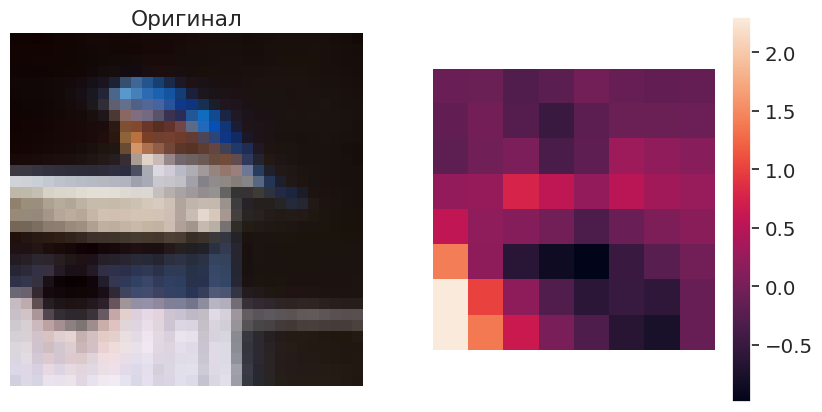

          Probs
plane  0.089155
car    0.126706
bird   0.286326
cat    0.048494
deer   0.024792
dog    0.017458
frog   0.000539
horse  0.154609
ship   0.052531
truck  0.199388


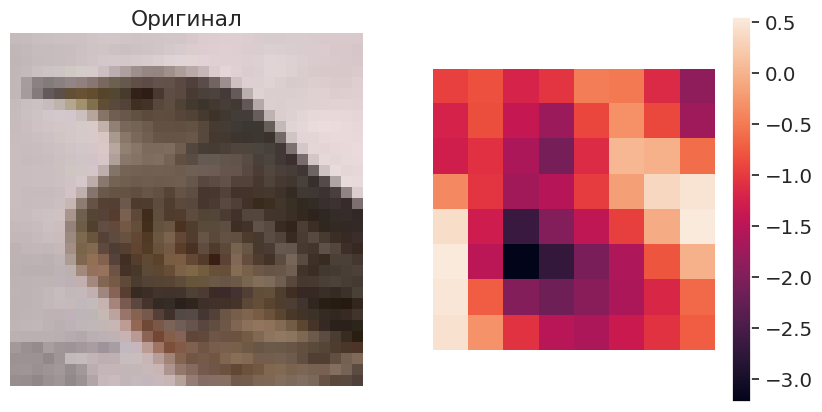

          Probs
plane  0.000376
car    0.000146
bird   0.056986
cat    0.234759
deer   0.006704
dog    0.008607
frog   0.685271
horse  0.005645
ship   0.000859
truck  0.000647


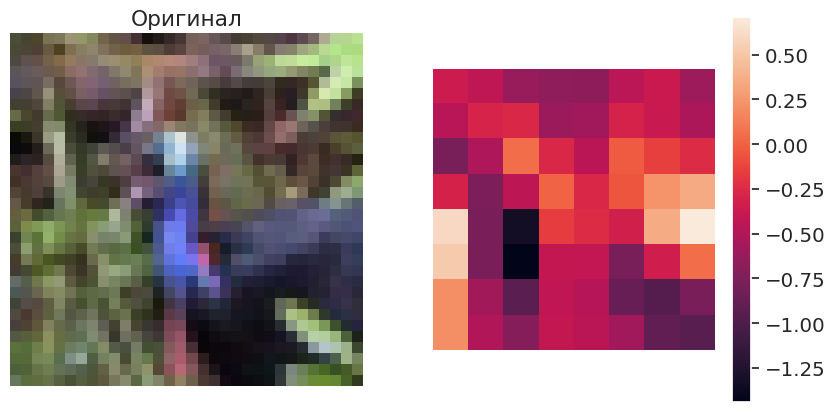

          Probs
plane  0.038879
car    0.003239
bird   0.774678
cat    0.016565
deer   0.117750
dog    0.037355
frog   0.004355
horse  0.002948
ship   0.000663
truck  0.003568


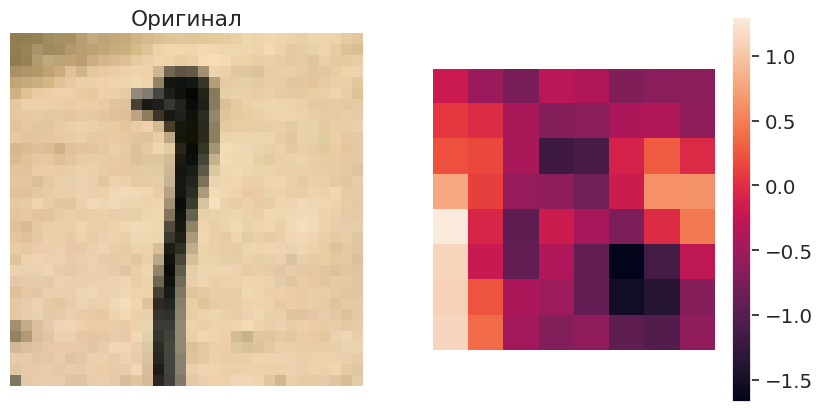

          Probs
plane  0.017018
car    0.001901
bird   0.393869
cat    0.052981
deer   0.226691
dog    0.080505
frog   0.000022
horse  0.225674
ship   0.000344
truck  0.000995


In [216]:
model.eval()
model.cpu()
occlusion = Occlusion(model.forward)

for idx in bird_idx:
    x0 = train_dataset[idx][0].cpu()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(x0.permute(1, 2, 0))
    axes[0].set_title("Оригинал")
    axes[0].axis("off")

    x = x0.unsqueeze(0) 
    attr = occlusion.attribute(
        x,
        target=class_idx,
        sliding_window_shapes=(3, 8, 8),
        strides=(3, 4, 4)
    )
    heatmap = heatmap = attr.squeeze(0).max(axis=0).values.detach().numpy()
    plt.imshow(heatmap)
    plt.axis('off')
    plt.colorbar()
    plt.show()
    print(pd.DataFrame(data={'Probs': nn.Softmax(dim=0)(model(x).squeeze(0)).detach().numpy()}, index=classes))

#### 4. Выводы
На основе выполненного задания сделайте выводы об особенностях работы сверток.

Таким образом свёрточные нейронные сети выделяют важные и неважные пиксели в каждом канале, учитывая их пространственное расположение. Несколько слоёв нейронной сети позволяют одновременно эффективно учитывать множество пикселей и уменьшить размерность исходного сэмпла, не теряя пространственных связей. Некоторые пиксели в их конфигурации фигурируют у определённых классов, эту закономерность сеть выучивает. Где-то края всегда острые, где-то - гладкие. Иногда. Чем глубже слой, тем сложнее закономерность пикселя может усмотреть модель: текстуры, свойственные рисунки

### Задача 2

**1.** В данной задаче вам предстоит реализовать метод оптимизации **Adam** (Adaptive Moment Estimation) путем создания собственного класса-оптимизатора в PyTorch. Предполагается следующая последовательность действий.


1. **Создание класса:** Разработайте класс `MyAdam`, наследуемый от `torch.optim.Optimizer`

2. **Реализация метода оптимизации:** Переопределите метод `step()`, содержащий логику метода `Adam`

3. **Поддержка параметров:** Реализуйте стандартные параметры метода:

    - `lr` — скорость обучения (learning rate);

    - `betas` — коэффициенты для вычисления скользящих средних моментов;

    - `eps` — малая константа для обеспечения численной стабильности;

    - `weight_decay` — коэффициент L2-регуляризации.

In [ ]:
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple

import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim
from IPython.display import clear_output, Image
from matplotlib import pyplot as plt
from torch.optim import Optimizer


sns.set(font_scale=1.6, palette="RdBu")

In [ ]:
class My_Adam(Optimizer):
    """Класс, реализующий алгоритм Adam (Adaptive Moment Estimation)."""

    def __init__(
        self,
        params: Iterable[torch.Tensor],
        lr: float = 1e-3,
        betas: Tuple[float, float] = (0.9, 0.999),
        eps: float = 1e-8,
        weight_decay: float = 0,
    ) -> None:
        """Инициализирует оптимизатор.

        Параметры:
            params: Итерируемый объект параметров для оптимизации
            lr (float): Learning rate (скорость обучения)
            betas (tuple): Коэффициенты для вычисления скользящих средних
            eps (float): Термин для численной стабильности

        """
        # Проверяем, что параметры корректны
        if lr <= 0:
            raise ValueError(f"Learning rate должен быть положительным: {lr}")
        if not 0 <= betas[0] < 1:
            raise ValueError(f"beta должен быть между 0 и 1: {betas[0] }")
        if not 0 <= betas[1] < 1:
            raise ValueError(f"mu должен быть между 0 и 1: {betas[1]}")
        if eps <= 0:
            raise ValueError(f"eps должен быть положительным: {eps}")

        # Установить параметры по умолчанию
        defaults = dict(...)
        super(My_Adam, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure: Optional[Callable[[], float]] = None) -> Optional[float]:
        """Выполняет один шаг оптимизации.

        Параметры:
            closure (callable, optional): Функция для перерасчета loss

        Возвращает:
            float: Значение loss если closure предоставлена, иначе None
        """

        loss = None

        if closure is not None:
            # Если передана closure функция, вычисляем loss
            with torch.enable_grad():
                loss = closure()

        # Пройти по всем группам параметров
        for group in self.param_groups:
            # Извлечь параметры группы
            lr = group["lr"]
            beta, mu = group["betas"]
            eps = group["eps"]
            weight_decay = group["weight_decay"]

            # Пройти по всем параметрам в группе
            for p in group["params"]:
                if p.grad is None:
                    continue

                ...

        return loss


По аналогии с реализацией класса `Adam` реализуйте метод оптимизации `NAdam` — модификацию Adam с ускорением Нестерова. Для этого добавьте параметр `momentum_decay`, который контролирует влияние момента Нестерова.

In [ ]:
class My_NAdam(Optimizer):
    """Класс, реализующий алгоритм NAdam."""

    def __init__(
        self,
        params: Iterable[torch.Tensor],
        lr: float = 1e-3,
        betas: Tuple[float, float] = (0.9, 0.999),
        eps: float = 1e-8,
        weight_decay: float = 0,
        momentum_decay: float = 0.004,
    ) -> None:
        """Инициализирует оптимизатор.

        Параметры:
            params: Итерируемый объект параметров для оптимизации
            lr (float): Learning rate (скорость обучения)
            betas (tuple): Коэффициенты для вычисления скользящих средних
            eps (float): Термин для численной стабильности

        """
        # Проверяем, что параметры корректны
        if lr <= 0:
            raise ValueError(f"Learning rate должен быть положительным: {lr}")
        if not 0 <= betas[0] < 1:
            raise ValueError(f"beta должен быть между 0 и 1: {betas[0]}")
        if not 0 <= betas[1] < 1:
            raise ValueError(f"mu должен быть между 0 и 1: {betas[1]}")
        if eps <= 0:
            raise ValueError(f"eps должен быть положительным: {eps}")
        if momentum_decay < 0:
            raise ValueError(f"momentum_decay должен быть неотрицательным: {momentum_decay}")

        # Установить параметры по умолчанию
        defaults = dict(...)
        super(My_NAdam, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure: Optional[Callable[[], float]] = None) -> Optional[float]:
        """Выполняет один шаг оптимизации.

        Параметры:
            closure (callable, optional): Функция для перерасчета loss

        Возвращает:
            float: Значение loss если closure предоставлена, иначе None
        """

        ...

        return loss

**2.** Проведем серию экспериментов для оценки работоспособности нашего оптимизатора.
Введем вспомогательную функцию.

Функция `make_experiment` визуализирует процесс оптимизации, отображая:

* линии уровня целевой функции в логарифмической шкале,

* траекторию движения алгоритма от начальной до конечной точки,

* стартовую (зеленая) и финальную (синяя) точки.

In [ ]:
def make_experiment(
    func: Callable[[torch.Tensor], float],
    trajectory: List[Tuple[float, float]],
    graph_title: str,
    xlim: Tuple[float, float] = (-7, 7),
    ylim: Tuple[float, float] = (-7, 7),
) -> None:
    """
    Функция, которая для заданной функции рисует её линии уровня,
    а также траекторию сходимости метода оптимизации.

    Параметры:
    1) func: Callable[[torch.Tensor], float] - оптимизируемая функция.
       Принимает 2D-тензор (координаты) и возвращает число (значение функции).
    2) trajectory: List[Tuple[float, float]] - траектория метода оптимизации.
       Список кортежей, где каждый кортеж - это (x, y) точка.
    3) graph_title: str - заголовок графика.
    4) xlim: Tuple[float, float] - кортеж с границами оси X (min_x, max_x).
    5) ylim: Tuple[float, float] - кортеж с границами оси Y (min_y, max_y).
    """

    fig, ax = plt.subplots(figsize=(10, 8))

    # Создаем сетку для линий уровня
    mesh_x = np.linspace(xlim[0], xlim[1], 300)
    mesh_y = np.linspace(ylim[0], ylim[1], 300)
    X, Y = np.meshgrid(mesh_x, mesh_y)
    Z = np.zeros((len(mesh_x), len(mesh_y)))

    # Вычисляем значения функции на сетке
    for coord_x in range(len(mesh_x)):
        for coord_y in range(len(mesh_y)):
            Z[coord_y, coord_x] = func(torch.tensor((mesh_x[coord_x], mesh_y[coord_y])))

    # Рисуем линии уровня
    ax.contour(X, Y, np.log(Z), np.log([0.5, 10, 30, 80, 130, 200, 300, 500, 900]), cmap="winter")

    # Рисуем всю траекторию целиком
    xdata = [point[0] for point in trajectory]
    ydata = [point[1] for point in trajectory]
    ax.plot(xdata, ydata, "ro-", markersize=4, linewidth=1)

    # Отмечаем начальную точку
    ax.plot(xdata[0], ydata[0], "go", markersize=8, label="Start")

    # Отмечаем конечную точку
    ax.plot(xdata[-1], ydata[-1], "bo", markersize=8, label="End")

    ax.set_title(graph_title)
    ax.legend()
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])

    plt.tight_layout()
    plt.show()

Проведите серию экспериментов по оптимизации. Для этого сравните свои классы `Adam` и `NAdam` с реализациями `Adam` и `NAdam` из `torch`. Для каждого метода попробуйте минимум 2 набора гиперпараметров.

Рассмотрите следующие функции

 $$
 f_1(x, y) = x^2 + y^2 + 10\sin 5x + 10\cos 5y
 $$

 $$
 f_2(x, y) = (1 - x)^2 + 100 \left(y - x^2 \right)^2
 $$

 $$
 f_3(x, y) = \left(x^2 + y - 11\right)^2 + \left(x + y^2 - 7\right)^2
 $$


Для каждой связки (*функция, оптимизатор, стартовая точка*) выполните следующие действия.

1. Создайте тензор `params` со стартовой точкой.

2. Создайте экземпляр оптимизатора, передав ему этот тензор с параметрами.

3. Создайте пустой список `trajectory` для сохранения истории точек $(x, y)$.

4. Проведите цикл оптимизации.

5. Для каждого эксперимента передайте полученный список `trajectory` в функцию `make_experiment`. Это позволит увидеть "путь" алгоритма по ландшафту функции.

6. Сравните поведение оптимизаторов на разных функциях.

### Задача 3 (Теория)

Рассмотрим полносвязную нейронную сеть из трех слоев, которая принимает на вход $x \in \mathbb{R}^{d_0}$ и возвращает $y \in \mathbb{R}^{d_3}$:

$$y_\theta(x) = \sigma_2 \big( \sigma_1 \left( x^{\top} W_1 + b_1 \right)^{\top} W_2 + b_2 \big)^{\top} W_3 + b_3,$$

где

* $W_1 \in \mathbb{R}^{d_0 \times d_1}, b_1 \in \mathbb{R}^{d_1}$ &mdash; параметры 1-го слоя,

* $W_2 \in \mathbb{R}^{d_1 \times d_2}, b_2 \in \mathbb{R}^{d_2}$ &mdash; параметры 2-го слоя,

* $W_3 \in \mathbb{R}^{d_2 \times d_3}, b_3 \in \mathbb{R}^{d_3}$ &mdash; параметры 3-го слоя,

* $\theta = (W_1, b_1, W_2, b_2, W_3, b_3)$ — все параметры нейросети,

* $\sigma_1(x), \sigma_1(x)$ &mdash; некоторые функции активации.

  

Пусть все веса инциализированы константой $c_1$, а все смещения &mdash; константой $с_2$. Покажите, что в процессе обучения данной нейросети ее параметры будут меняться следующим образом.
* Веса $W_1$ могут поменяться, и не обязательно будут одинаковыми; аналогично с весами $W_3$ и смещением $b_3$.
* Веса $W_2$ также могут поменять свое значение, но в каждый момент времени это значение будет одинаковым для всех весов $W_2$; аналогично со смещениями $b_1$ и $b_2$.

Обобщите это утверждение на случай большего количества слоев в нейронной сети.

In [218]:
import base64
from IPython.display import Markdown, display
def embed_image(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    md = f'<img src="data:image/png;base64,{data}" width="800">'
    display(Markdown(md))

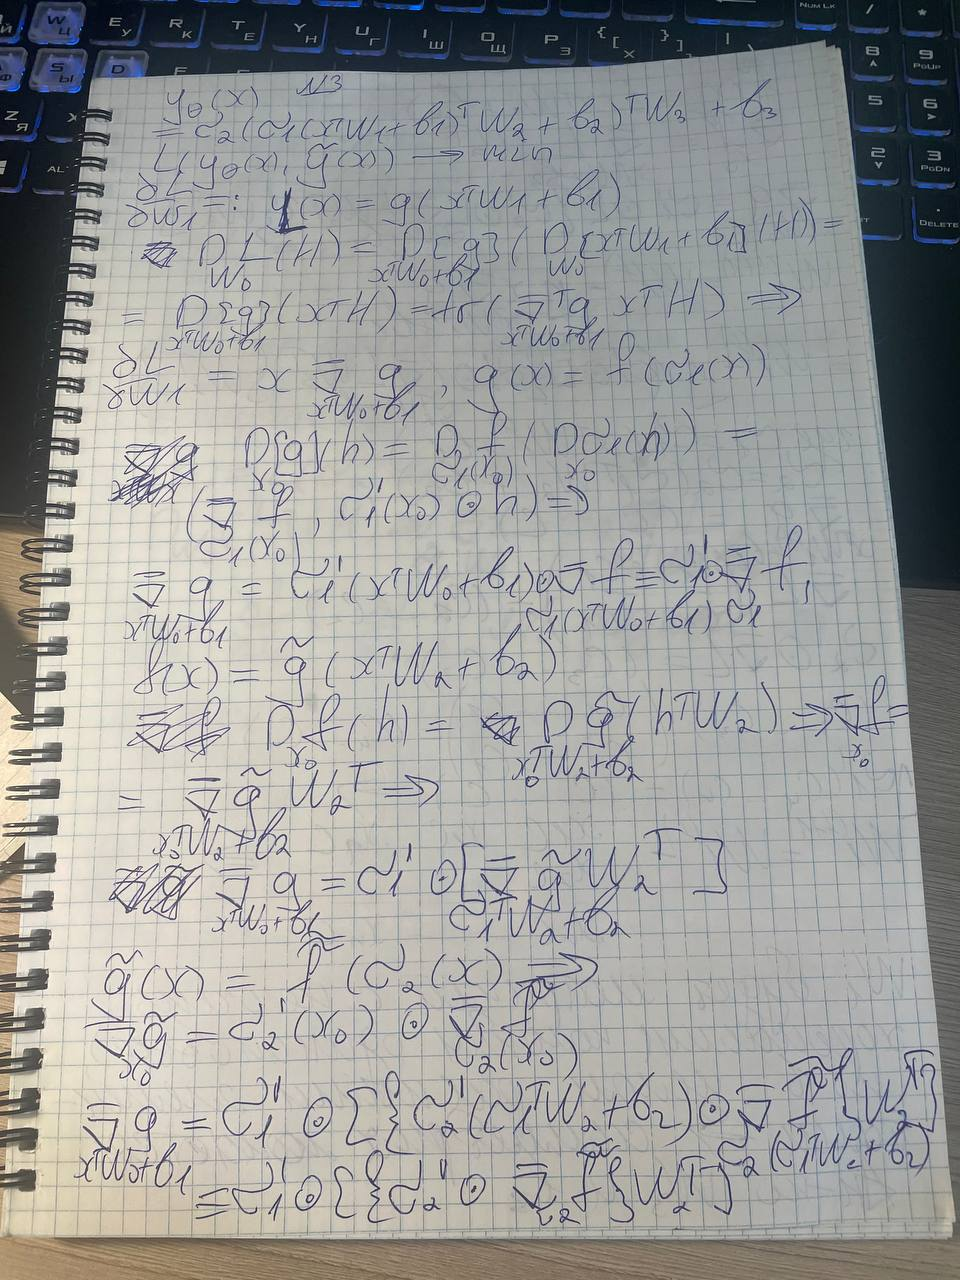

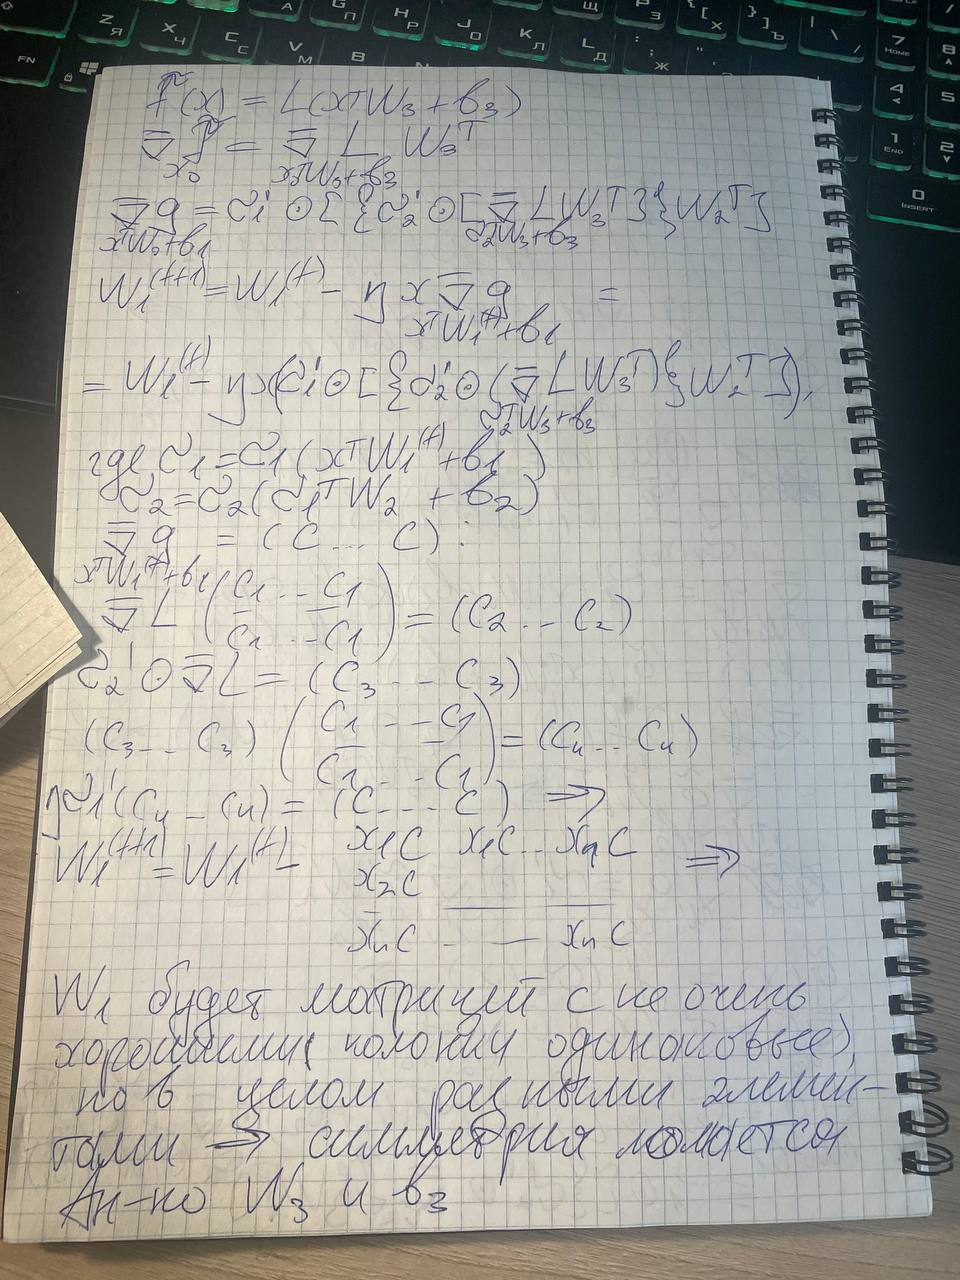

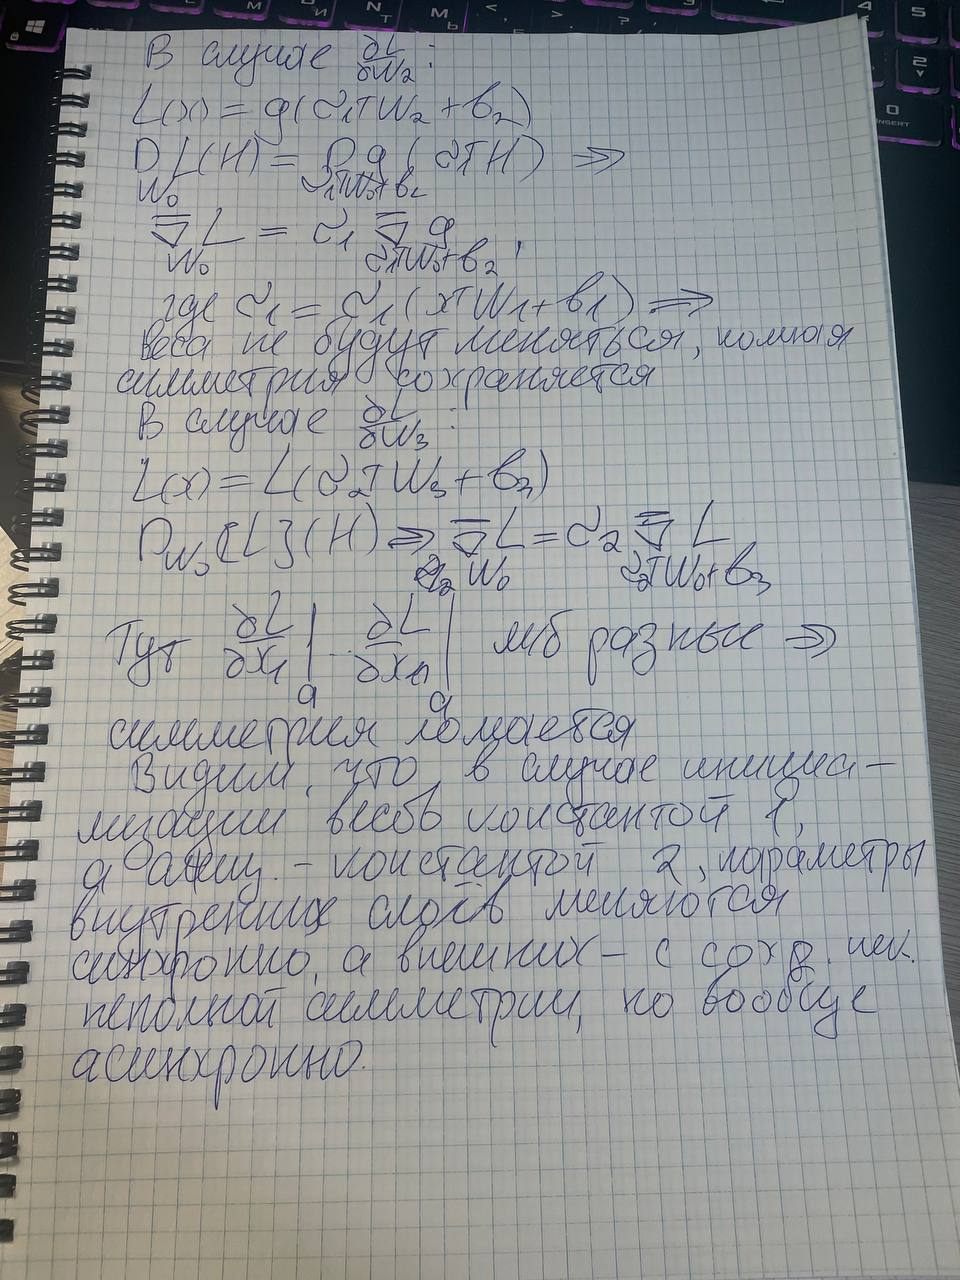

In [222]:
embed_image('1.jpg')
embed_image('2.jpg')
embed_image('3.jpg')

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока